## Coursework Project
## Part 2

In [6]:
import sqlite3
import pandas as pd
import os

In [8]:
# Create a connection to the database 

conn = sqlite3.connect('flights_python1.db')

In [3]:
## create table
airports = pd.read_csv("airports.csv")
carriers = pd.read_csv("carriers.csv")
planes = pd.read_csv("plane-data.csv")

airports.to_sql("airports", conn, if_exists="replace", index=False)
carriers.to_sql("carriers", conn, if_exists="replace", index=False)
planes.to_sql("planes", conn, if_exists="replace", index=False)

5029

In [4]:
c = conn.cursor()

In [5]:
c.execute("DROP TABLE IF EXISTS ontime")

c.execute('''
CREATE TABLE ontime (
  Year int,
  Month int,
  DayofMonth int,
  DayOfWeek int,
  DepTime  int,
  CRSDepTime int,
  ArrTime int,
  CRSArrTime int,
  UniqueCarrier varchar(5),
  FlightNum int,
  TailNum varchar(8),
  ActualElapsedTime int,
  CRSElapsedTime int,
  AirTime int,
  ArrDelay int,
  DepDelay int,
  Origin varchar(3),
  Dest varchar(3),
  Distance int,
  TaxiIn int,
  TaxiOut int,
  Cancelled int,
  CancellationCode varchar(1),
  Diverted varchar(1),
  CarrierDelay int,
  WeatherDelay int,
  NASDelay int,
  SecurityDelay int,
  LateAircraftDelay int
)
''')

conn.commit()

In [6]:
# Load from csv.bz2 files
for year in range(2001, 2006):
    filename = str(year)+".csv.bz2"
    print('Processing:', filename)
    ontime = pd.read_csv(filename, encoding="latin-1", compression='bz2')
    ontime.to_sql('ontime', con = conn, if_exists = 'append', index = False)

conn.commit()

Processing: 2001.csv.bz2
Processing: 2002.csv.bz2
Processing: 2003.csv.bz2


C:\Users\Joeen\AppData\Local\Temp\ipykernel_16712\586844651.py:5: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  ontime = pd.read_csv(filename, encoding="latin-1", compression='bz2')


Processing: 2004.csv.bz2
Processing: 2005.csv.bz2


# Part 2(a) Best times and days to minimize delays

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Query: Average delay by departure time
query_time = """
SELECT (CAST(DepTime / 100 AS INTEGER) + (DepTime % 100) / 60.0) AS DepHour,
       AVG(ArrDelay) AS AvgDelay
FROM ontime
WHERE ArrDelay IS NOT NULL AND DepTime IS NOT NULL AND DepTime >= 0 AND DepTime < 2400
GROUP BY DepHour
ORDER BY DepHour;
"""

# Execute the query and store the results in a DataFrame
flights_time = pd.read_sql(query_time, conn)

# Convert delay from minutes to hours
flights_time["AvgDelay"] = flights_time["AvgDelay"] / 60  

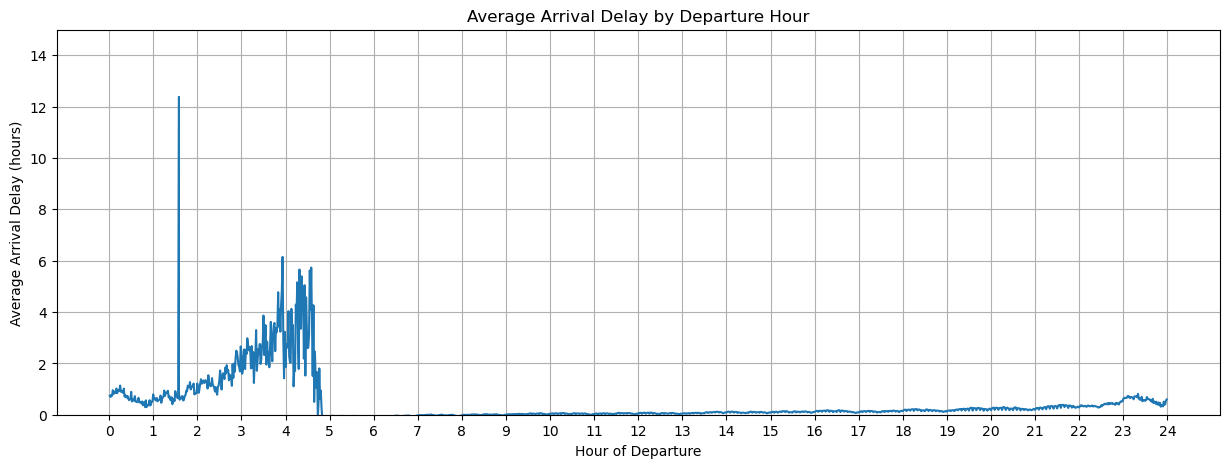

In [29]:
# Plot delay by departure hour
plt.figure(figsize=(15, 5))
sns.lineplot(x=flights_time["DepHour"], y=flights_time["AvgDelay"])
plt.xlabel("Hour of Departure")
plt.ylabel("Average Arrival Delay (hours)")
plt.title("Average Arrival Delay by Departure Hour")
plt.xticks(range(0, 25, 1))
plt.grid(True)
plt.ylim(0, 15)
plt.show()

In [27]:
# Query: Average delay by day of the week
query_day = """
SELECT DayOfWeek, AVG(ArrDelay) AS AvgDelay
FROM ontime
WHERE ArrDelay IS NOT NULL
GROUP BY DayOfWeek
ORDER BY DayOfWeek;
"""
flights_day = pd.read_sql(query_day, conn)


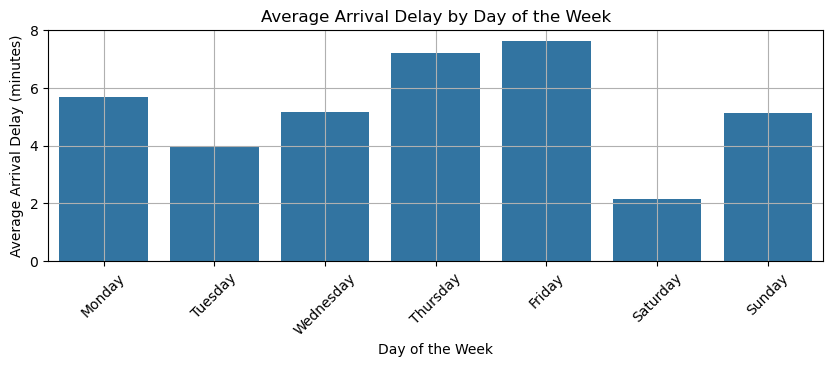

In [29]:
# Mapping DayOfWeek to actual weekday names
day_mapping = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 
               5: "Friday", 6: "Saturday", 7: "Sunday"}
flights_day["DayOfWeek"] = flights_day["DayOfWeek"].map(day_mapping)

# Plot delay by day of the week
plt.figure(figsize=(10, 3))
sns.barplot(x=flights_day["DayOfWeek"], y=flights_day["AvgDelay"], order=day_mapping.values())
plt.xlabel("Day of the Week")
plt.ylabel("Average Arrival Delay (minutes)")
plt.title("Average Arrival Delay by Day of the Week")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Part 2(b) Do Older Planes Have More Delays?

In [39]:
# Query: Relationship between aircraft age and delay
query_plane_delay_yearly = """
SELECT f.Year AS Year,
       f.Year - p.year AS PlaneAge,
       AVG(f.ArrDelay) AS AvgDelay
FROM ontime f
JOIN planes p ON f.TailNum = p.tailnum
WHERE f.ArrDelay IS NOT NULL
  AND p.year IS NOT NULL
  AND f.Year BETWEEN 2001 AND 2005
GROUP BY f.Year, PlaneAge
ORDER BY f.Year, PlaneAge
"""

df_yearly = pd.read_sql(query_plane_delay_yearly, conn)

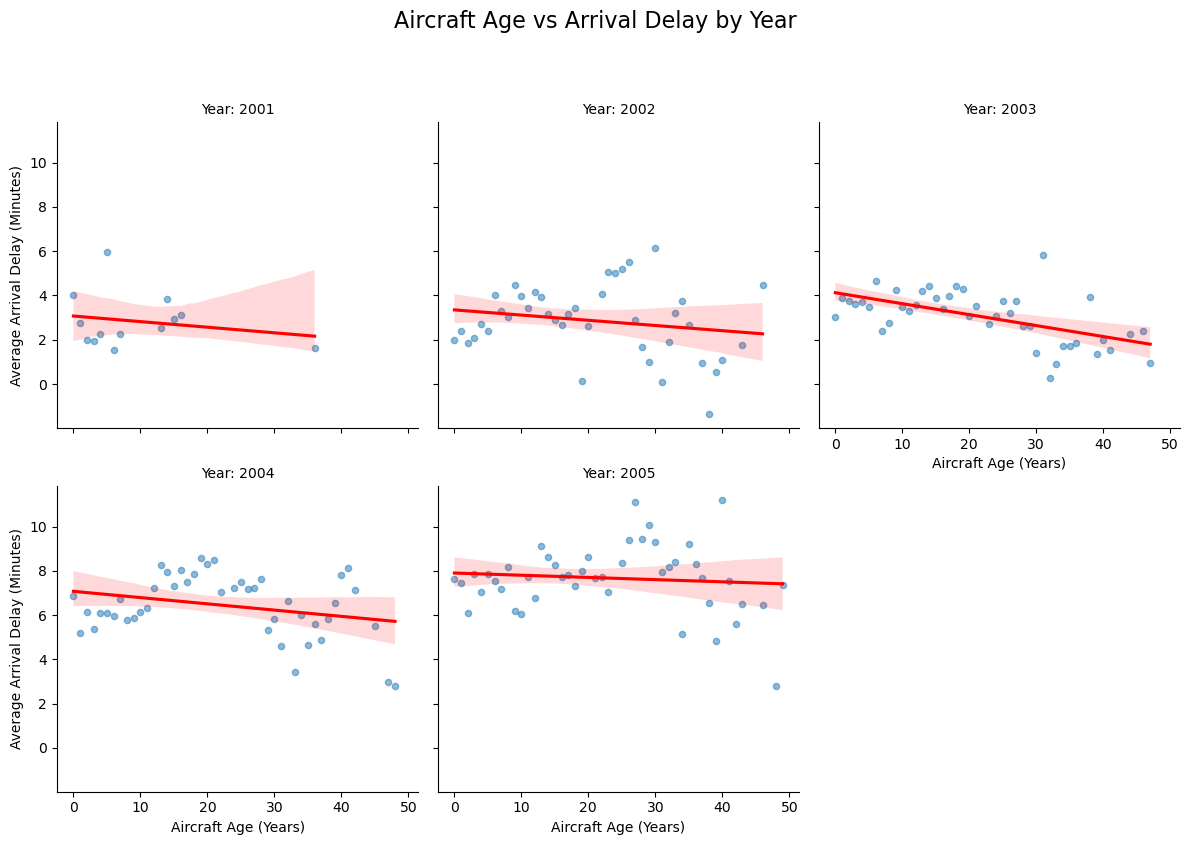

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter unreasonable data
df_filtered = df_yearly[(df_yearly["PlaneAge"] >= 0) & (df_yearly["PlaneAge"] < 50)]

# A faceted plot for each year
g = sns.lmplot(
    data=df_filtered,
    x="PlaneAge", y="AvgDelay",
    col="Year", col_wrap=3,
    height=4, aspect=1,
    scatter_kws={"s": 20, "alpha": 0.5},
    line_kws={"color": "red"}
)

g.set_axis_labels("Aircraft Age (Years)", "Average Arrival Delay (Minutes)")
g.set_titles("Year: {col_name}")
plt.suptitle("Aircraft Age vs Arrival Delay by Year", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

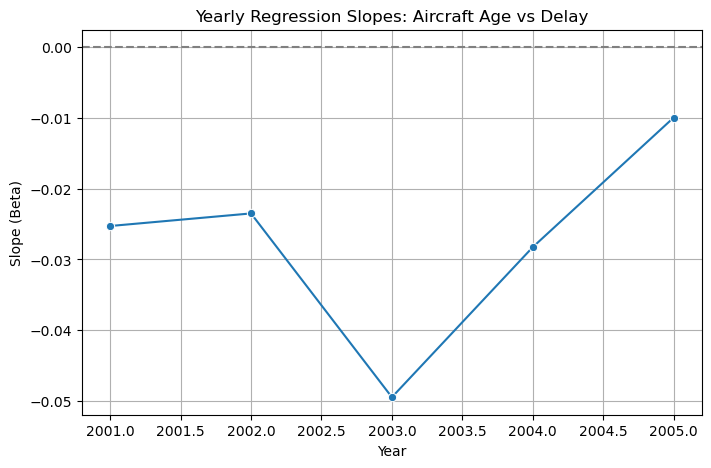

In [49]:
import statsmodels.api as sm

slopes = []
years = sorted(df_filtered["Year"].unique())

for year in years:
    data_year = df_filtered[df_filtered["Year"] == year]
    X = sm.add_constant(data_year["PlaneAge"])
    y = data_year["AvgDelay"]
    model = sm.OLS(y, X).fit()
    slopes.append(model.params["PlaneAge"])

# # Plot the slope (trend strength) for each year）
plt.figure(figsize=(8, 5))
sns.lineplot(x=years, y=slopes, marker="o")
plt.title("Yearly Regression Slopes: Aircraft Age vs Delay")
plt.xlabel("Year")
plt.ylabel("Slope (Beta)")
plt.axhline(0, linestyle="--", color="gray")
plt.grid(True)
plt.show()

## Part 2 (c）Logistic Regression for Diverted Flights

In [5]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import gc

In [79]:
# Count Diverted = 0 and 1 for each year
divert_counts = []

for year in range(2001, 2006):
    query = f"""
    SELECT Diverted, COUNT(*) as count
    FROM ontime
    WHERE Year = {year}
    GROUP BY Diverted;
    """
    df_year_counts = pd.read_sql(query, conn)
    df_year_counts["Year"] = year
    divert_counts.append(df_year_counts)

# Combine all year counts into one DataFrame
df_divert_summary = pd.concat(divert_counts, ignore_index=True)
df_divert_summary = df_divert_summary.pivot(index="Year", columns="Diverted", values="count").fillna(0)
df_divert_summary.columns = ["Not Diverted (0)", "Diverted (1)"]

# Print summary table
print("\nFlight Diversion Counts by Year:")
print(df_divert_summary.astype(int).to_string())



Flight Diversion Counts by Year:
      Not Diverted (0)  Diverted (1)
Year                                
2001           5954871         12909
2002           5263003          8356
2003           6477159         11381
2004           7115486         13784
2005           7126568         14028


In [7]:
# Define feature categories
numerical_features = [
    "Month", "DayofMonth", "DayOfWeek", "DepTime", "CRSDepTime", "ArrTime", "CRSArrTime", 
    "Distance"
]
categorical_features = ["UniqueCarrier"] 

In [9]:
# Use these as full feature names for OneHotEncoder
all_features = numerical_features + categorical_features

In [11]:
# Store coefficients across years
coef_results = {}
all_metrics = []
all_coef_dfs = []

In [13]:
# Loop through each year
for year in range(2001, 2006):
    print(f"\nProcessing Year: {year}")

    query = f"""
    SELECT Year, {", ".join(all_features)}, Diverted
    FROM ontime
    WHERE Year = {year};
    """

    chunk_size = 100000
    model = LogisticRegression(max_iter=1000, solver="lbfgs", class_weight="balanced")
    fitted_transformer = None

    for i, chunk in enumerate(pd.read_sql(query, conn, chunksize=chunk_size)):
        X = chunk[all_features]
        y = chunk["Diverted"].astype(int)
        
        if y.nunique() < 2:
            continue

        # Define ColumnTransformer with named input features
        data_transformer = ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler())
            ]), numerical_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                                     drop=None))  
            ]), categorical_features)
        ])

        # Fit transformer on first chunk
        if fitted_transformer is None:
            fitted_transformer = data_transformer.fit(X)

        # Transform features
        X_transformed = fitted_transformer.transform(X)

        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_transformed, y, test_size=0.2, stratify=y, random_state=42
        )

        # Resample
        smote = SMOTE(sampling_strategy=0.7, random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

        model.fit(X_train_resampled, y_train_resampled)

    # Get clean feature names from fitted transformer
    numerical_names = numerical_features
    categorical_names = list(
        fitted_transformer.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(input_features=categorical_features)
    )

    feature_names = numerical_names + categorical_names
    coef_series = pd.Series(model.coef_[0], index=feature_names)

    # Store result
    coef_results[year] = coef_series.sort_values(key=abs, ascending=False)

    # Store all for plotting
    df_year_coef = pd.DataFrame({
        "feature": coef_series.index,
        "coefficient": coef_series.values,
        "year": year
    })
    all_coef_dfs.append(df_year_coef)

    # Metrics
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_prob)

    all_metrics.append({"Year": year, "Accuracy": acc, "Recall": rec, "AUC": auc})
    print(f"Year {year} | Accuracy: {acc:.4f}, Recall: {rec:.4f}, AUC: {auc:.4f}")

    gc.collect()

conn.close()


Processing Year: 2001
Year 2001 | Accuracy: 0.6826, Recall: 0.7037, AUC: 0.7172

Processing Year: 2002
Year 2002 | Accuracy: 0.6272, Recall: 0.6429, AUC: 0.6565

Processing Year: 2003
Year 2003 | Accuracy: 0.6255, Recall: 0.5758, AUC: 0.6099

Processing Year: 2004
Year 2004 | Accuracy: 0.7731, Recall: 0.6667, AUC: 0.6867

Processing Year: 2005
Year 2005 | Accuracy: 0.7319, Recall: 0.5455, AUC: 0.6626


In [15]:
# Display metrics
df_metrics = pd.DataFrame(all_metrics)
print("\nModel Performance Summary:")
print(df_metrics)


Model Performance Summary:
   Year  Accuracy    Recall       AUC
0  2001  0.682650  0.703704  0.717219
1  2002  0.627172  0.642857  0.656497
2  2003  0.625536  0.575758  0.609949
3  2004  0.773147  0.666667  0.686737
4  2005  0.731897  0.545455  0.662586


In [17]:
# Combine all coefficients
coef_all_years_df = pd.concat(all_coef_dfs, ignore_index=True)

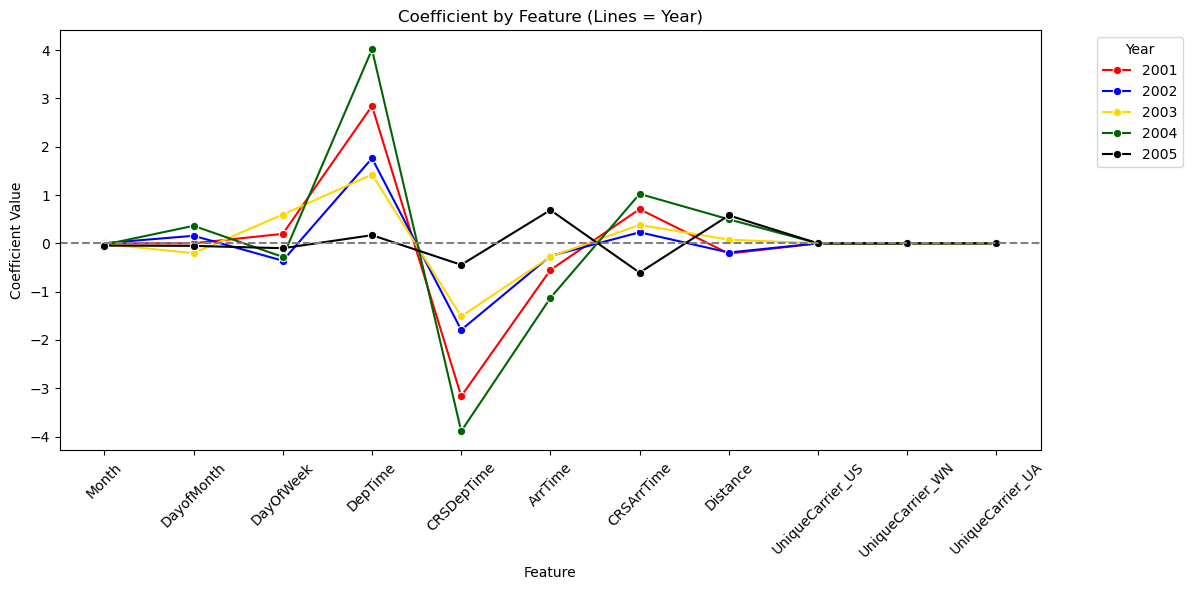

In [19]:
# Plot (X = feature name, Y = coefficient, line = year)
top_features = (
    coef_all_years_df["feature"]
    .value_counts()
    .index.tolist()
)

plot_df = coef_all_years_df[coef_all_years_df["feature"].isin(top_features)]

custom_palette = {
    2001: "red",
    2002: "blue",
    2003: "gold",
    2004: "darkgreen",
    2005: "black"
}

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=plot_df,
    x="feature",
    y="coefficient",
    hue="year",
    palette=custom_palette,
    marker="o"
)

plt.title("Coefficient by Feature (Lines = Year)")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.axhline(0, linestyle="--", color="gray")
plt.xticks(rotation=45)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()